::: {.callout-tip collapse="true"}
## TLDR

Running an ONNX model in ONNX RunTime (ORT) with the CoreMLExecutionProvider may change the predictions your model makes implicitly and you may observe differences when running with PyTorch on MPS or ONNX on CPU. <b>This is because the default arguments ORT uses when converting your model to CoreML will cast the model to FP16</b>.

The fix is to use the following setup when creating the InferenceSession:

```Python
ort_session = ort.InferenceSession(onnx_model_path, providers=[("CoreMLExecutionProvider", {"ModelFormat": "MLProgram"})])
```

This ensures your model remains in FP32 when running on a Mac GPU.
:::

## Uncovering an Issue in ONNX Runtime - Benchmarking the EyesOff Model

Having trained the [EyesOff model](https://ym2132.github.io/building_EyesOff_part2_model_training), I began evaluating the model and its run time. I was looking into the ONNX format and using it to run the model efficiently. I setup a little test bench in which I ran the model using PyTorch and ONNX with ONNX Runtime (ORT), both using MPS and CPU. While checking the outputs, I noticed that the metrics from the model ran on ONNX on MPS had a different output to those on ONNX CPU and PyTorch CPU and MPS. Note, the metrics from PyTorch on CPU and MPS were the same. 

When I say ORT and MPS, this is achieved through ORT's execution providers. To run an ONNX model on the Mac GPU you have to use the CoreMLExecutionProvider (more on this to come).

Now in Figure 1 and 2, observe the metric values - the PyTorch ones (Figure 1) are the same across CPU and MPS, this isn't the same story for ONNX (Figure 2):

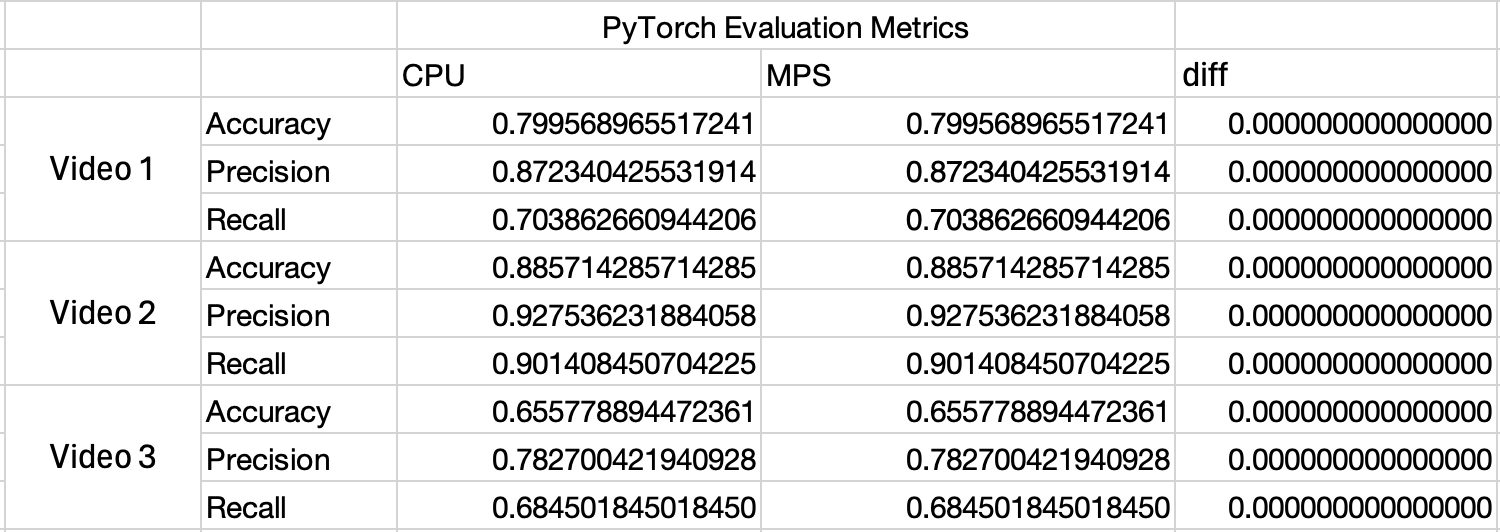

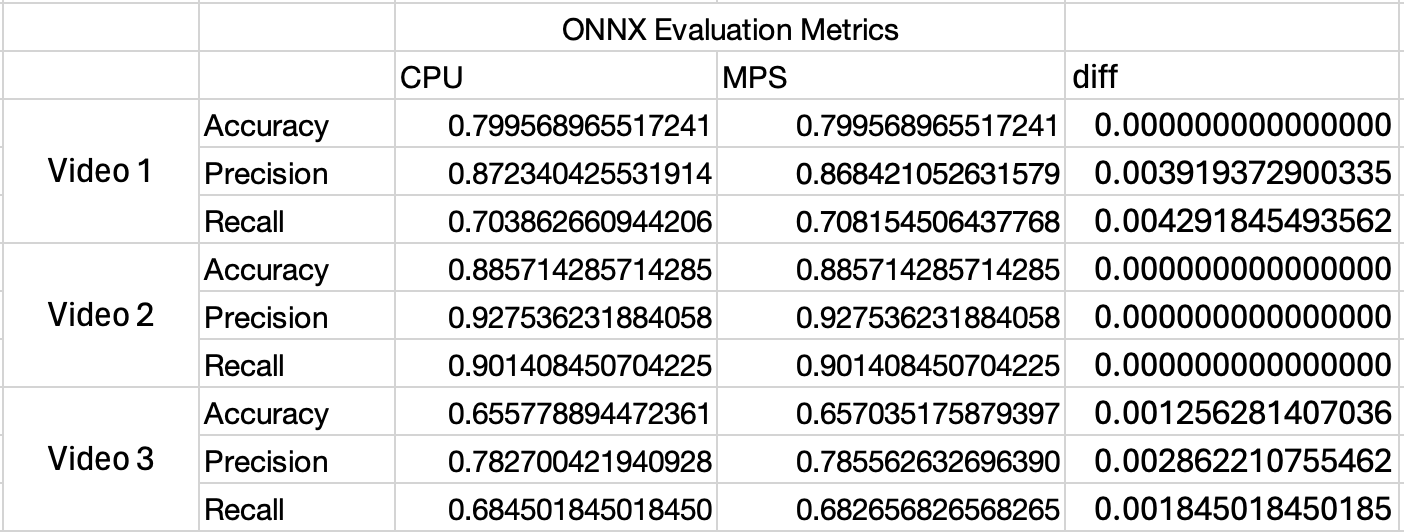

Wow, look at the diff in Figure 2! When I saw this it was quite concerning, floating point math can lead to differences in the calculations carried out across the GPU and CPU but the values here don't appear to be a result of floating point math, the values are too large. 

Given the difference in metrics, I was worried that running the model with ORT was changing the output of the model and hence the behaviour. The reason the metrics change is because some of the model predictions around the threshold flipped to the opposite side of the threshold (which is 0.5), this can be seen in the confusion matrices for the ONNX CPU run and MPS run:

#### FP32 Confusion Matrix

|                    | **Predicted Negative** | **Predicted Positive** |
|-------------------:|:----------------------:|:----------------------:|
| **Actual Negative** |          207 (TN)      |         24 (FP)        |
| **Actual Positive** |           69 (FN)      |        164 (TP)        |

#### FP16 Confusion Matrix

|                    | **Predicted Negative** | **Predicted Positive** |
|-------------------:|:----------------------:|:----------------------:|
| **Actual Negative** |          206 (TN)      |         25 (FP)        |
| **Actual Positive** |           68 (FN)      |        165 (TP)        |

So two predictions flipped from negative to positive. 

Having said that, the first thing I did was to make my life easier, by simplifying the scenario from the large EyesOff model to a simple one layer MLP and using that to run the experiments.

## Why am I Using ONNX and ONNX RunTime?

Before going on it's worth discussing what ONNX and ORT are, and why I'm even using them in the first place.

### ONNX[<sup>1</sup>](#1)

ONNX stands for Open Neural Network Exchange. It can be thought of as a common programming language in which to describe ML models. Under the hood ONNX models are represented as graphs, these graphs outline the computation path of a model and it shows the operators and transformations required to get from input to prediction. These graphs are called ONNX graphs. 

The use of a common language to describe models makes deployment easier and in some cases can add efficiency in terms of resource usage + or inference speed. Firstly, the ONNX graph itself can be optimised. Take PyTorch for example, you train the model in it and sure PyTorch is very mature and extremely optimised but it's such a large package some things can be overlooked or difficult to change. By converting the model to ONNX, you take advantage of the fact that ONNX was built specifically with inference in mind and with that comes optimisations which the PyTorch team could implement but have not yet. 

Furthermore, ONNX models can be ran cross platform in specialised runtimes. These runtimes are specially optimised for different architectures and add another layer of efficiency gains.

### ONNX RunTime (ORT)[<sup>2</sup>](#2)

ORT is one of these runtimes. ORT actually runs the model, it can be though of as an interpreter, it takes the ONNX graph and actually implements the operators and runs them on the specified hardware. ORT has a lot of magic built into it, the operators are extremely optimised and through the use of execution providers they target a wide range of hardware. Each execution provider is optimised for the specific hardware it refers to, this enables the ORT team to implement extremely efficient operators giving us another efficiency gain.

### CoreML[<sup>3</sup>](#3)

As mentioned before, I used the CoreMLExecutionProvider to run the model on a Mac GPU. This execution provider informs ORT to make use of CoreML. CoreML is an apple developed framework which lets models (neural networks and classical ML models) run on Apple hardware, CPU, GPU and ANE. ORT's purpose in this phase is to take the ONNX graph and convert it to a CoreML model. CoreML is Apple's answer to running efficient on device models on Apple hardware. 

Note, that all of this doesn't always mean the model will run faster. Some models may run faster in PyTorch, TensorRT or any other framework. This is why it is important to benchmark and test as many approaches as makes sense.

## Finding the Source of the CPU vs MPS Difference - With an MLP

The MLP used is very simple it has a single layer, with 4 inputs, 3 outputs and the bias turned off. So, I pretty much created a fancy matrix multiplication.

To understand where the issue was coming from I ran this MLP through some different setups:
    
    - PyTorch CPU
    - PyTorch MPS
    - ORT CPU
    - ORT MPS
    - CoreML FP32
    - CoreML FP16

The goal of this exercise is to find out if 1 - the difference in outputs is seen in a simple model and 2 - to figure out where exactly the issue arises.

Before showing the full results, I want to explain why I included the CoreML FP16 and FP32 runs - specifically why the FP16 one. When I initially ran the MLP experiment I only ran PyTorch, ORT and CoreML FP32 but the output numbers of ORT MPS looked like FP16 numbers. So, I tested if they were and also if the outputs from the other runs were true FP32 numbers. You can do this with a "round trip" test, by converting a number to FP16 and back to FP32. If after this process the number is unchanged then it is an FP16 number but if it changes then it was a true FP32. The number changes as FP16 can represent fewer floating point numbers than FP32. It's a very simple check to carry out:

```Python
import numpy as np

onnx_cpu = np.array([0.6480752, -0.34015813, 1.4329923], dtype=np.float32)
onnx_coreml = np.array([0.6484375, -0.34033203, 1.4326172], dtype=np.float32)  # We cast the ort MPS numbers up to FP32, if they were FP16 this has no effect

cpu_roundtrip = onnx_cpu.astype(np.float16).astype(np.float32)
coreml_roundtrip = onnx_coreml.astype(np.float16).astype(np.float32)

print("ORT CPU values:")
print("  Original:", onnx_cpu)
print("  fp16 roundtrip:", cpu_roundtrip)
print("  Changed?", not np.allclose(onnx_cpu, cpu_roundtrip, atol=0))

print("\nORT CoreML values:")
print("  Original:", onnx_coreml)
print("  fp16 roundtrip:", coreml_roundtrip)
print("  Changed?", not np.allclose(onnx_coreml, coreml_roundtrip, atol=0))
```

The output of this is:

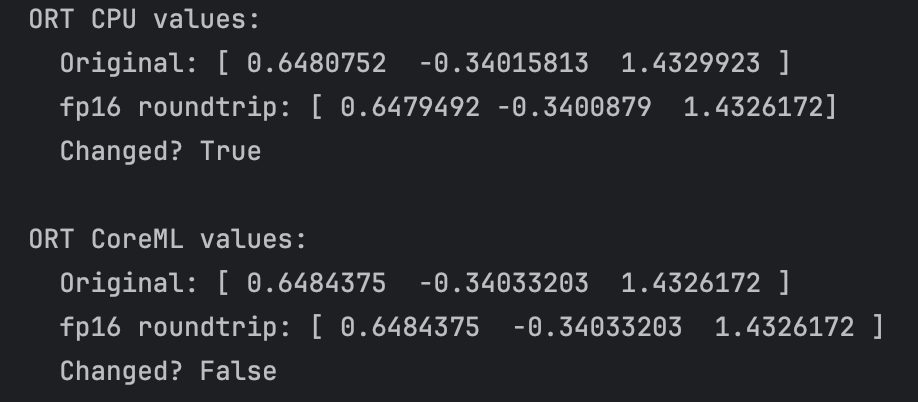

The CPU values change and the MPS values don't! Now it's getting interesting - perhaps when using the CoreML execution provider the output is FP16? This prompted adding the CoreML direct run in FP16 precision.

I tested this theory with an experiment. Originally, when benchmarking it was all about inference speed, now it's about floating point precision and figuring out where the diffs come from. 

Running on PyTorch CPU and MPS gives a strong baseline, PyTorch is a very mature ecosystem and I used the results from that as my ground truth. It being so close together is what drove me to understand what caused ORT runs on different hardware to have a difference. Then using CoreML FP32 and FP16 aimed to show if the issue was an ONNX one or a CoreML one.

Check Figure 4 for the outputs and Figure 5 for differences in the outputs here:

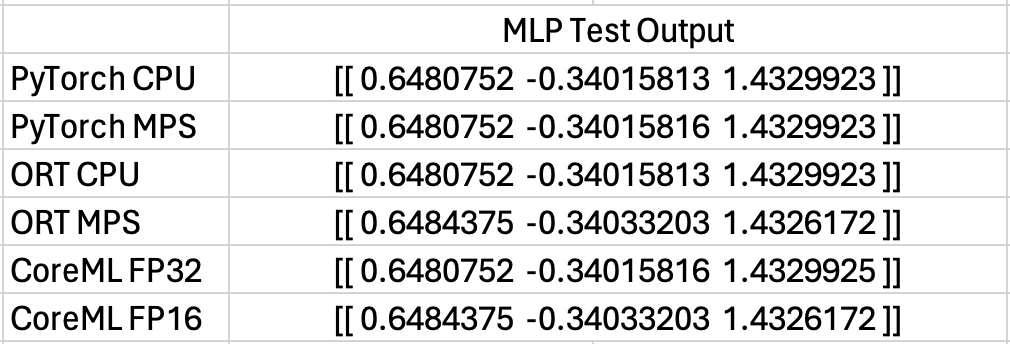

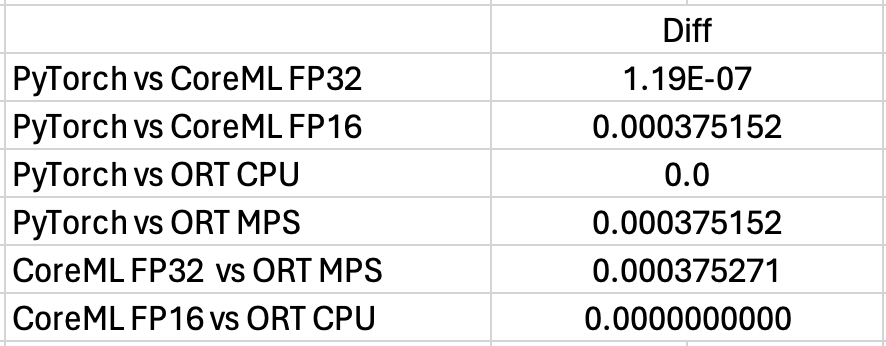

Wow, would you look at that - once again PyTorch + ORT CPU match and so does PyTorch CPU + CoreML FP32. Also note that CoreML FP16 and ORT MPS match! This is a big insight into what is happening and why the metrics output differed before. Along with the round trip experiment this proves our model is being ran in FP16 when using the CoreML execution provider in ORT! 

::: {.callout-tip collapse="true"}
### A Refresher on Floating Points (FP)

Floating points numbers are defined by three values:
  
  - **Sign**: 1 bit to define if the number is positive or negative
  - **Significand**: Contains the numbers digits
  - **Exponent**: This says where the decimal place should be placed relative to the beginning of the significand

Floating point numbers are often expressed in scientific notation, e.g:

![Figure 8 - Table showing Significand, Exponent and scientific representation[<sup>6</sup>](#6)](attachment:0a8652d6-7911-4b0c-bb00-525a245bff41.png)

FP16 and FP32 specifically, have the following specification:

| Format | Total bits | Significand bits | Exponent bits | Smallest number | Largest number |
|--------|------------|------------------|---------------|-----------------|----------------|
| Single precision | 32 | 23 + 1 sign | 8 | $1.2 * 10^{-38}$ | $3.4 * 10^{38}$ |
| Half precision | 16 | 10 + 1 sign | 5 | $5.96 * 10^{-8}$ | $6.55 * 10^{4}$ |

So as FP16 is half the size it affords a couple benefits, firstly it requires half the memory to store and secondly it can be quicker to do computations with too. However, this comes at a cost of precision, FP16 cannot represent very small numbers and the distances between small numbers as accurately as FP32. 

An example of FP16 vs FP32 - The Largest Number Below 1

  - FP32 - 0.999999940395355225[<sup>4</sup>](#4)
  - FP16 - 0.99951172[<sup>5</sup>](#5) 

As you see FP32 can represent a value much closer to 1. 

#### The Link to the ONNX Issue

Having said all that, going back to the issue at hand we observe a ~$1.17*e^{-7}$ error between PyTorch and CoreML FP32 which is typical of FP32. But, then ORT and CoreML when ran on MPS have a difference of ~$3.7*e{-4}$ which is much more representative of FP16, this is what prompted the round trip experiment.

:::

::: {.callout-tip collapse="true"}
### So Why Do the Predictions Flip - A Slightly Deeper Look Into FP16 Values

If you need a quick refresher on FP values, please expand the box above. If you already read that or you know enough about FP already let's look at why some predictions flip.

In my model the base threshold for a 0 or 1 class is 0.5. Both FP16 and FP32 can represent 0.5 exactly:

```Python
fp_32_05 = np.array([0.5], dtype=np.float32)
fp_16_05 = np.array([0.5], dtype=np.float16)
fp_32_05.item(), fp_16_05.item()

(0.5, 0.5)
```

But we know that FP representations cannot represent every single number, so there will be some values around 0.5 which cannot be represented and hence will get rounded either up or down. Let's look into that and find the threshold, this will show why some predictions of the EyesOff model were flipped when changing the model to run in FP16. Also, note by flipped we mean they go from a negative (0) prediction to a positive (1) class prediction, the rounding means it'd have to be below 0.5 and then be rounded up to cross the threshold boundary. Any other scenario would keep the label the same, i.e if it's above 0.5 and gets rounded to 0.5 that's fine as the predicted class is still the same.

The first step is to find the next representable number below 0.5:

```Python
# Show the representable values just below 0.5
fp32_below = np.nextafter(np.float32(0.5), np.float32(0.0))
fp16_below = np.nextafter(np.float16(0.5), np.float16(0.0))

fp32_gap = 0.5 - fp32_below
fp16_gap = 0.5 - fp16_below

print(f"\nClosest value BELOW 0.5:")
print(f"FP32: {fp32_below:.20f}")
print(f"FP16: {fp16_below:.20f}")

print(f"\nGap from threshold (0.5):")
print(f"FP32: {fp32_gap:.2e}")
print(f"FP16: {fp16_gap:.2e}")
```
```Text
Closest value BELOW 0.5:
FP32: 0.49999997019767761230
FP16: 0.49975585937500000000

Gap from threshold (0.5):
FP32: 2.98e-08
FP16: 2.44e-04
```

Taking this gap between 0.5 and the next reprsentable number below 0.5 in FP16 we can calculate the threshold for values which will get rounded up to 0.5:

```Python
# Given the gap is 2.44e-04, we need to divide it by 2 and calculate the midpoint between 0.499755859375 and 0.5. This midpoint determines whether the FP16 value will be rounded down if below it or up it equal to or greater than. 

# Convert to FP32 as the midpoint is not representable in FP16
fp_16_below_fp32 = np.float32(fp16_below)

# Calculate the gap and midpoint
fp16_gap = 0.5 - fp16_below
midpoint = fp_16_below_fp32 + (fp16_gap / 2)

print(f"  Midpoint (rounding boundary): {midpoint:.15f}")
```
```Text
Midpoint: 0.499877929687500
```

Finally let's see some examples of numbers being rounded up to 0.5 if they are above the midpoint between the representable values of FP16:

```Python
# Firstly, the midpoint itself is rounded up
np.float16(0.499877929687500).item() -> 0.5
np.float16(0.4999).item() -> 0.5

# For completeness here's a number slightly smaller than the midpoint which gets rounded down
np.float16(0.4998779296874).item() -> 0.499755859375
```

In short, any number between $[0.4998779296875, 0.5)$ will be rounded up to 0.5. This means, the predictions which were flipped were in this range.
:::
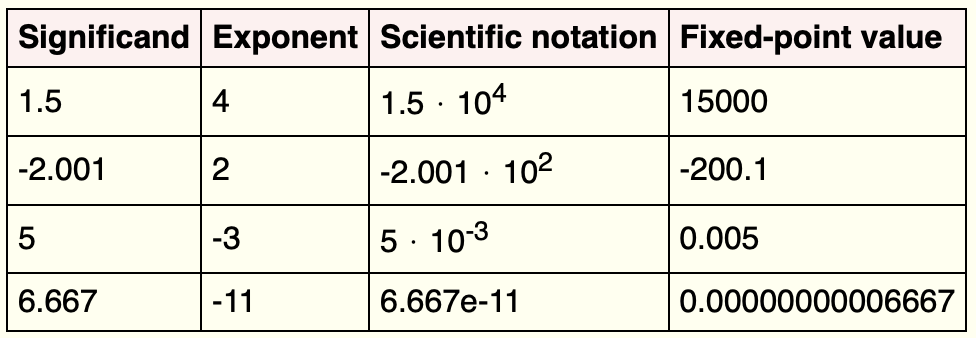

## Where Does the Model Switch to FP16?

Now that we know what the issue is, it's time to find out what caused it.

### A Bug or Intended Behaviour - It Must be a Bug Right...? 

Originally I thought this behaviour was a bug with the ORT repo. Knowing the cast occured in the phase where ORT takes the ONNX model and converts it to a CoreML model my initial thinking was either ORT casts it to FP16 somewhere or calls CoreML with a hardcode FP16 flag or something similar.

Having little background in cpp, [Claude](https://claude.ai) came in useful here. I gave it the structure of the repo and it told me where I ought to place breakpoints to debug the ORT package (turns out you can debug a cpp package from python, clone the repo, build from src and then link it to your python code using the PID). However, upon running the code the breakpoints weren't being hit. I was puzzled for a bit, but then I realised why the code wasn't being hit. It turns out CoreML has two model formats "NeuralNetwork" and "MLProgram", I will call them NN and MLP formats respectively. The behaviour of the ORT repo changes depending on which you want, as does the behaviour of CoreML, with the default being the NN format. So, the breakpoints weren't hit as the code was regarding the MLP format whereas I was not setting this so the code flowed through the default NN code. Knowing this I took a step back and began experimenting with NN vs MLP format.

## The Fix - NeuralNetwork vs MLProgram CoreML Format

So, CoreML has two model formats, these represent how the model is stored and ran with CoreML. The NeuralNetwork (NN) format is older and the MLProgram (MLP) format is newer. ORT specifies NN format by default, but it does allow you to pass a flag to use MLP format. 

Testing the MLP format revealed it as the solution! See below in figure 6 the final output, which includes both ORT MLP and NN format ran on the GPU.

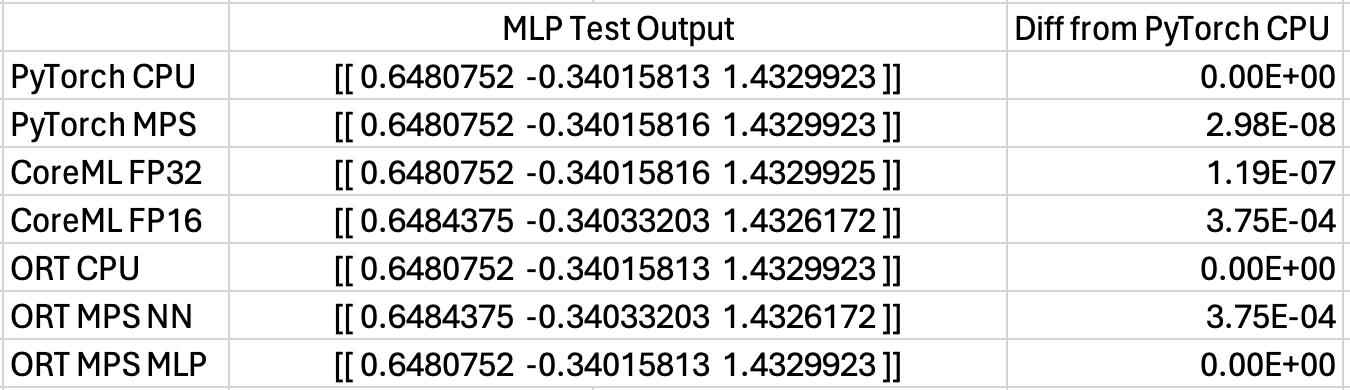

So ORT on MPS with NN format has the same difference from the PyTorch CPU baseline as CoreML FP16, whereas ORT with MLP format matches - this is exactly what I wanted. Mystery solved! By setting the model format to be the newer MLProgram format no implicit cast to FP16 takes place. 

## Why MLProgram Format Worked and Neural Network Didnt?

To understand the difference in behaviours of these two models formats we need to take a deep dive on the internals of CoreML, its goals and the two formats themselves. Let's begin with CoreML.

### CoreML

ORT implements methods to convert the ONNX graph into CoreML model formats. CoreML has two types of model format, this defines how the model is represented in the CoreML framework, how it's stored and how it's ran. The older is the NeuralNetwork format and the newer one which solved our issue is the MLProgram format. The reason MLProgram keeps the model at FP32 when running on MPS is due to the differences in model representation in these two formats. Let's take a look at both of them.

### Neural Network Format

As stated, the NN format is the older one, it came out in 2017. It stored models as a Directed Acyclic Graph (DAG). Each layer in the model is a node in the DAG, and they encode information on layer type, list of input names, output names and a collection of parameters specific to the layer type[<sup>7</sup>](#7). We can observe the model which is created by ORT's InferenceSession call with the following code:

```Python
# First create the InferenceSession and run the model. This ensures the CoreML model files are added to a temp dir
ort = ort.InferenceSession(
    onnx_path, providers=["CoreMLExecutionProvider"]
)
nn_output = ort.run(None, {"input": numpy_input})[0]

import coremltools as ct

def get_coreml_dtype_from_spec(path):
    """Extract model type and dtypes by reading the spec."""
    
    model = ct.models.MLModel(str(path))
    spec = model.get_spec()

    print(f"\nModel Spec for {path.name}:\n {spec}\n")

# Find created models
temp_dir = Path(tempfile.gettempdir())

# NeuralNetwork models are .mlmodel files
nn_files = list(temp_dir.glob("*.mlmodel"))

for model_path in nn_files:
    info = get_coreml_dtype_from_spec(model_path)
```

This outputs the following:

```Text
Model Spec for onnxruntime-40975D85-7412-4309-A6F7-4E51CA3D2FE8-7682-0000BF11C24C3150.model.mlmodel:
 specificationVersion: 4
description {
  input {
    name: "input"
    type {
      multiArrayType {
        shape: 1
        shape: 4
        dataType: FLOAT32
      }
    }
  }
  output {
    name: "output"
    type {
      multiArrayType {
        shape: 1
        shape: 3
        dataType: FLOAT32
      }
    }
  }
}
neuralNetwork {
  layers {
    name: "node_linear"
    input: "input"
    output: "output"
    innerProduct {
      inputChannels: 4
      outputChannels: 3
      weights {
        floatValue: 0.0349225402
        floatValue: -0.301196814
        floatValue: 0.159211695
        floatValue: 0.156890273
        floatValue: -0.267238438
        floatValue: -0.0749385953
        floatValue: -0.292913973
        floatValue: 0.129736364
        floatValue: -0.134683847
        floatValue: 0.351268351
        floatValue: 0.354943156
        floatValue: 0.0509352088
      }
    }
  }
  arrayInputShapeMapping: EXACT_ARRAY_MAPPING
}
```

NeuralNetwork format has typed input and output to the model, but the nodes themselves are not typed. This is why the model gets cast to FP16, in the NN format the default behaviour is to <b>run in FP16 on the MPS GPU</b>. This quirk of the NN format is what threw off my results[<sup>8</sup>](#8). The CoreML runtime also specifies which parts of the model operators can run on which hardware[<sup>9</sup>](#9) and each hardware has different abilities in terms of what FP values it can handle with the NN format. Take a look at Figure 7 for Apple's guide on the hardware and FP types they can handle:

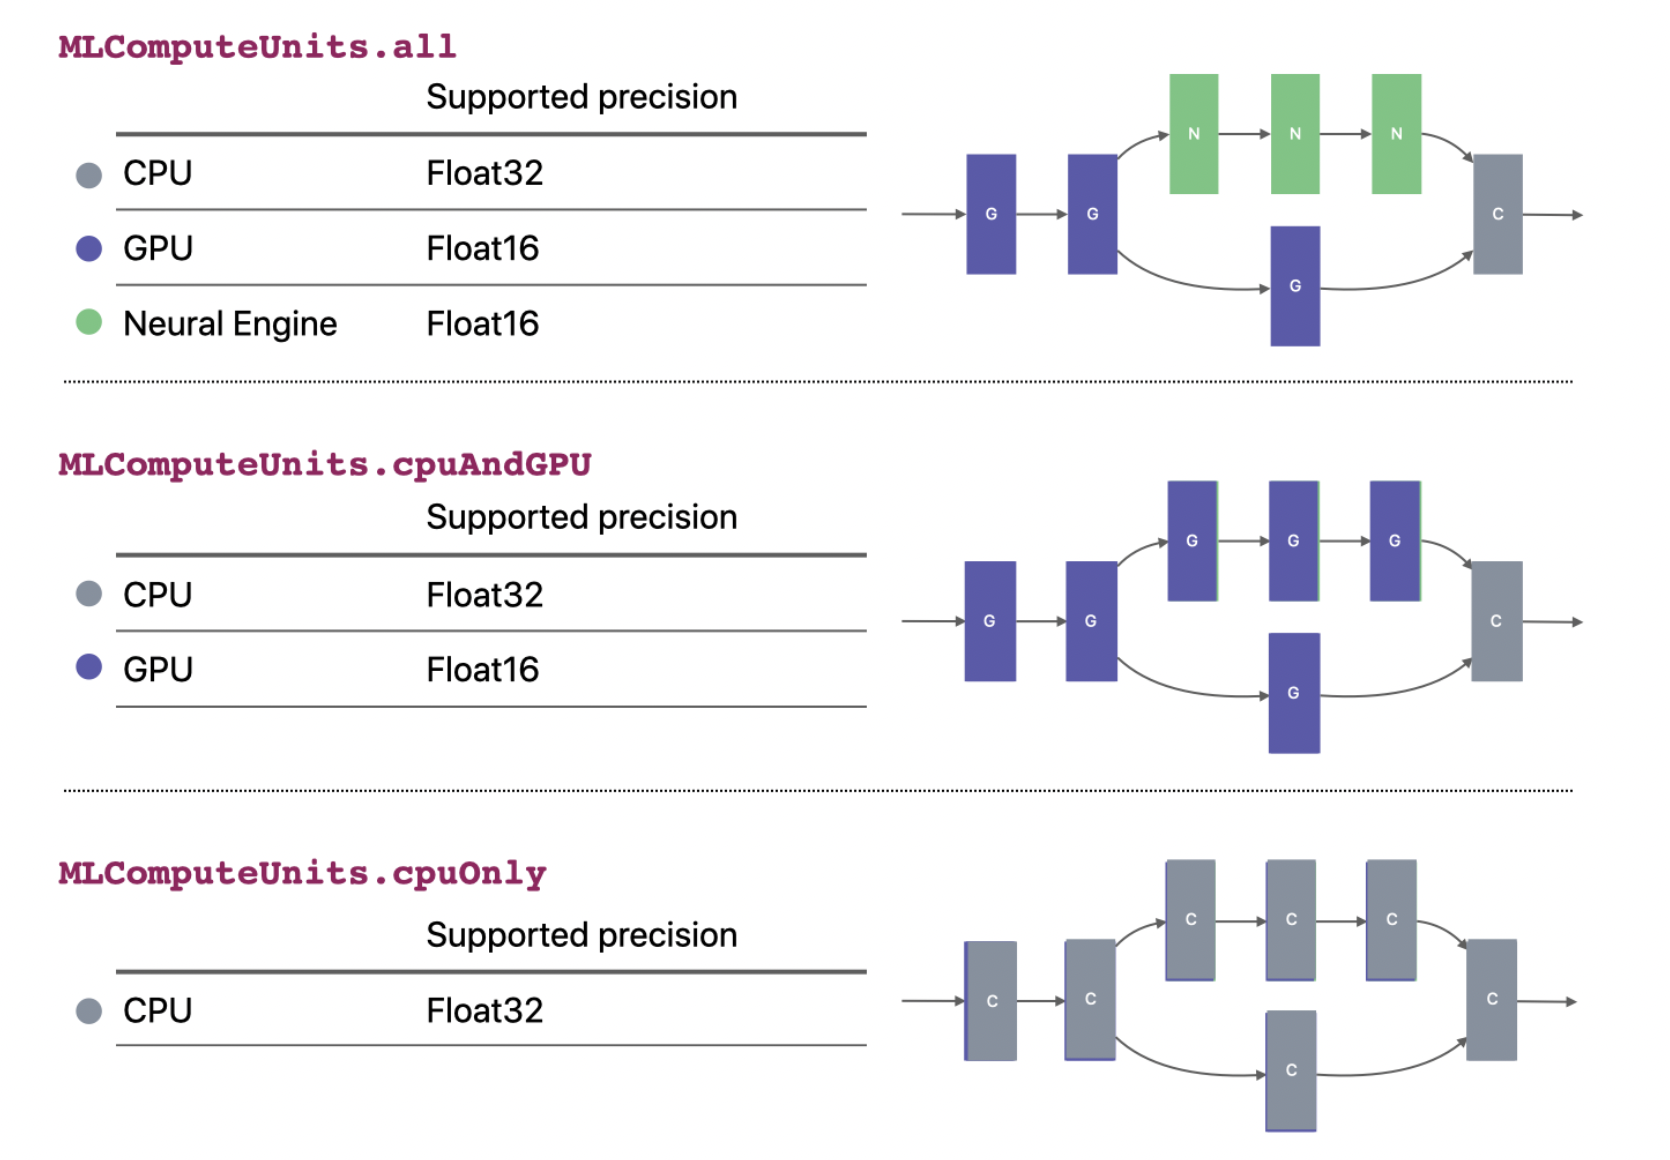

When running on CPU the NN format model will run in FP32, as we observed. However, on GPU it is implicitly cast to FP16 even though the input and output are specified to be FP32 as you see in the inspection code above. This is an inherent limitation of the NN format. The DAG structure of the model <b>does not store any information on the types of intermediate layers</b>. You can see this in the inspection output, the part beginning neuralNetwork stored info on the actual layer node, in our case a single linear layer. Observe that there is no information on the FP precision of the node itself, hence CoreML implicitly sets it to FP16. 

#### Why Does CoreML Implicitly Use FP16

From the typed execution docs for coremltools, the goal of CoreML is to run ML models in the most performant way and FP16 happens to be more performant than FP32 (which makes sense as it's half the precision) on Apple GPUs. Also, they state that most of the time the reduced precision doesn't matter for inference - this whole blog post shows why this is false and a pitfall of the NN format, <b>the user should choose which precision the model is ran in, it should never be implicit</b>. 

##### MatMul Test - Is FP16 Faster on Apple Hardware?

To test Apple's claim that FP16 is more performant on Apple hardware I carried out a large matmul. Taking a 16384x16384 matrix and multiplying it with another 16384x16384 matrix should show us if FP16 is faster. The size is arbitrary I just wanted something large. 

The matmul was ran 10 times, <b>in both FP32 and FP16 on the MPS hardware</b>, and we take the average:

```Text
FP32 Average Time: 8.6521 seconds
FP16 Average Time: 6.7691 seconds

Speedup Factor: 1.28x faster
```
So FP16 is quicker, which sheds a bit of light on why the NN format has implicit casting to FP16, on paper if you only care about speed then it's the better option.

Final point on the NeuralNetwork format, it's surprising as the weights themselves are stored as FP32 values (a roundtrip test verifies this) but it still executes that layer in FP16, once again showing the NN format doesn't respect the FP precision of the layer but just casts it to FP16.

All that is to say this, this was <b>not a bug</b> but rather an explicit design choice, which funnily enough involves implicitly going against what the user wants. The NN format has its downsides, which is why Apple introduced the MLProgram format, let's look into that.

### The MLProgram (MLP) Format

The MLP format is the newer and better model format in CoreML, released in 2021, the core thing we care about is that the intermediate tensors are typed, i.e. there is no implicit casting when using the MLP format - the user controls whether the model is ran in FP16 or FP32. 

MLP format allows for this as it uses a different representation of ML models, instead of a DAG it uses a programmatic representation of the models. By representing the model as code, it allows for greater control over the operations. 

Let's see what this looks like in the stored model format and how it differs to the NN format inspection.

The code to do so is pretty similar:

```Python
# First create the InferenceSession and run the model. This ensures the CoreML model files are added to a temp dir. Also
# this time we specify the ModelFormat to be MLProgram 
ort_mlp = ort.InferenceSession(
    onnx_path, providers=[("CoreMLExecutionProvider", {"ModelFormat": "MLProgram"})]
)
mlp_output = ort_mlp.run(None, {"input": numpy_input})[0]

import coremltools as ct

def get_coreml_dtype_from_spec(path):
    """Extract model type and dtypes by reading the spec."""
    
    model = ct.models.MLModel(str(path))
    spec = model.get_spec()

    print(f"\nModel Spec for {path.name}:\n {spec}\n")

# Find created models
temp_dir = Path(tempfile.gettempdir())

# MLProgram models are in onnxruntime-* directories (not .mlmodelc)
mlp_dirs = [d for d in temp_dir.glob("onnxruntime-*")
            if d.is_dir() and not str(d).endswith('.mlmodelc')]

for model_path in mlp_dirs:
    info = get_coreml_dtype_from_spec(model_path)
```

The output of this is the following:

```Text
Model Spec for onnxruntime-752039B9-BA73-47E3-9ED4-AE029184DA69-9443-0000BF278CD8396E:
 specificationVersion: 8
description {
  input {
    name: "input"
    type {
      multiArrayType {
        shape: 1
        shape: 4
        dataType: FLOAT32
      }
    }
  }
  output {
    name: "output"
    type {
      multiArrayType {
        shape: 1
        shape: 3
        dataType: FLOAT32
      }
    }
  }
}
mlProgram {
  version: 1
  functions {
    key: "main"
    value {
      inputs {
        name: "input"
        type {
          tensorType {
            dataType: FLOAT32
            rank: 2
            dimensions {
              constant {
                size: 1
              }
            }
            dimensions {
              constant {
                size: 4
              }
            }
          }
        }
      }
      opset: "CoreML7"
      block_specializations {
        key: "CoreML7"
        value {
          outputs: "output"
          operations {
            type: "const"
            outputs {
              name: "linear_weight"
              type {
                tensorType {
                  dataType: FLOAT32
                  rank: 2
                  dimensions {
                    constant {
                      size: 3
                    }
                  }
                  dimensions {
                    constant {
                      size: 4
                    }
                  }
                }
              }
            }
            attributes {
              key: "val"
              value {
                type {
                  tensorType {
                    dataType: FLOAT32
                    rank: 2
                    dimensions {
                      constant {
                        size: 3
                      }
                    }
                    dimensions {
                      constant {
                        size: 4
                      }
                    }
                  }
                }
                blobFileValue {
                  fileName: "@model_path/weights/weight.bin"
                  offset: 64
                }
              }
            }
            attributes {
              key: "name"
              value {
                type {
                  tensorType {
                    dataType: STRING
                  }
                }
                immediateValue {
                  tensor {
                    strings {
                      values: "linear_weight"
                    }
                  }
                }
              }
            }
          }
          operations {
            type: "linear"
            inputs {
              key: "x"
              value {
                arguments {
                  name: "input"
                }
              }
            }
            inputs {
              key: "weight"
              value {
                arguments {
                  name: "linear_weight"
                }
              }
            }
            outputs {
              name: "output"
              type {
                tensorType {
                  dataType: FLOAT32
                  rank: 2
                  dimensions {
                    constant {
                      size: 1
                    }
                  }
                  dimensions {
                    constant {
                      size: 3
                    }
                  }
                }
              }
            }
            attributes {
              key: "name"
              value {
                type {
                  tensorType {
                    dataType: STRING
                  }
                }
                immediateValue {
                  tensor {
                    strings {
                      values: "node_linear__0"
                    }
                  }
                }
              }
            }
          }
        }
      }
    }
  }
}
```

Now you see in the inspection of the MLP format model the linear layer is <b>explicitly typed</b>. To make it a bit easier to see let's bring back the NeuralNetwork format inspection and compare the <b>linear layer setup</b> in both:

#### Linear Layer in NeuralNetwork & MLProgram Format

<table>
<tr>
<th>NeuralNetwork Linear Layer</th>
<th>MLProgram Linear Layer</th>
</tr>
<tr>
<td>

<pre>
neuralNetwork {
  layers {
    name: "node_linear"
    input: "input"
    output: "output"
    innerProduct {
      inputChannels: 4
      outputChannels: 3
      weights {
        floatValue: 0.0349225402
        floatValue: -0.301196814
        floatValue: 0.159211695
        floatValue: 0.156890273
        floatValue: -0.267238438
        floatValue: -0.0749385953
        floatValue: -0.292913973
        floatValue: 0.129736364
        floatValue: -0.134683847
        floatValue: 0.351268351
        floatValue: 0.354943156
        floatValue: 0.0509352088
      }
    }
  }
</pre>

</td>
<td>

<pre>
operations {
    type: "linear"
    inputs {
      key: "x"
      value {
        arguments {
          name: "input"
        }
      }
    }
    inputs {
      key: "weight"
      value {
        arguments {
          name: "linear_weight"
        }
      }
    }
    outputs {
      name: "output"
      type {
        tensorType {
          dataType: FLOAT32
          rank: 2
          dimensions {
            constant {
              size: 1
            }
          }
          dimensions {
            constant {
              size: 3
            }
          }
        }
      }
    }
</pre>

</td>
</tr>
</table>

Observe in the NN format, there is no explicit mention of the input or output type also the model weights are stored with the layer. Now, in the MLProgram layer, the output is explicitly typed as FP32. No more pesky implicit casting to FP16! This is one the big changes in MLProgram vs NN format, secondly notice how the layer weights are not stored along with the spec, they're stored elsewhere. This aspect also makes the MLP format more efficient as the actual model spec is lighter. 

## But Why Does MLProgram Have Typed Layers?

So we've come to the end of the journey, we found that NeuralNetwork format lacks types in the intermediate layers of the model and MLProgram doesn't. So, setting ORT to use MLProgram keeps the model at FP32 and our output predictions remain the same when running in PyTorch and ORT. But why, why does NeuralNetwork not include types? Answering this requires a look into how ML models have been represented in the past and how this has evolved over time.

### Design Choices, Design Choices - How Goals of ML Optimisation Evolved Over Time

When the NeuralNetwork format was released in 2017, it came into a much different environment than the one MLProgram was born into in 2021. The goal of NeuralNetwork was to act as a <b>configuration file to be ran by hardware</b>, as we saw above it defines the layers and the weights without much other info and lets the hardware figure out the rest. This is indicative of the trends in ML at the time, models were still being optimised so the added complexity wasn't yet needed, the DAG representation worked well. 

In essence, the NN format assumes that if the weights are stored in FP32, the input is FP32 and the output is too then the intermediate layers will also be FP32 - <b>but</b> as it doesn't explicitly type these intermediate layers the hardware is free to choose and the Apple GPU chooses FP16 by default!

As time went on the demands in the ML world changed, these hardware based quirks became known, optimisations advanced and overall the industry moved away from the splintered (splintered in the sense that many frameworks implemented their own) config style DAGs and began to utilise learnings from the world of compilers

### Changes From 2017 to 2021 Which Lead to Greater Adoption of Intermediate Representations

Firstly, for Apple specifically the hardware available expanded, now you have the CPU, GPU and ANE chips - making it very difficult to assume any given piece of hardware will run a specific FP type. Also, the lack of typing leads to other issues namely the compiler cannot make some optimisations, as they depend on knowing the types before runtime. Furthermore, things like mixed FP training and quantization became a thing, once again highlighting the need for explicit typing.

Lastly, in 2017 DAGs and other forms of model compilers were very fragmented and modern times have seen a push towards standardisation[<sup>10</sup>](#10), as the compiler community consolidated on tools like LLVM the ML community has too. Intermediate Representations(IR) began to be used in ML, an IR is a hardware agnostic specification of a program which a compiler can optimise. CoreML introduced their own IR, called MIL (Model Intermediate Language) and it implements the output we see in the stored MLProgram output.

### The MIL Approach

MIL and IRs in general afford a lot of benefits. They are inherently designed for optimisation and by providing a general framework you can extract maximal value as all optimisation engineers can work on a common goal. In MIL specifically, some of the changes we've discussed between NN and MLProgram format, are implemented by it. Namely, each variable within the model has an <b>explicit</b> dtype.

Note, the MLProgram serialises and stores the output of the MIL phase, we've already observed how it differs to the the NeuralNetwork model, with the biggest difference being in the explicit types. 

#### Further Reading on ML Compilers
[https://huyenchip.com/2021/09/07/a-friendly-introduction-to-machine-learning-compilers-and-optimizers.html](https://huyenchip.com/2021/09/07/a-friendly-introduction-to-machine-learning-compilers-and-optimizers.html)

## Takeaways

### The Fix

The solution to all the issues we discussed today is, if you are using the <b>CoreMLExecutionProvider</b> in ORT then be sure to specify <b>ModelFormat is MLProgram</b>, this will ensure that whatever precision your model was trained it will be ran with that - which in my case was FP32 (whereas the default ModelFormat NeuralNetwork casts the model to FP16).

You can implement this as such:

```Python
ort_session = ort.InferenceSession(onnx_model_path, providers=[("CoreMLExecutionProvider", {"ModelFormat": "MLProgram"})])
```

### The Cause

The issue was the differing model formats employed by CoreML to represent ML models. The NeuralNetwork format utilised a more historic DAG based approach which was developed during a time in which types and precision wasn't a huge concern in the ML community and hardware decisions were left to the hardware. Whereas the MLProgram format used a programmatic approach, in which types are explicit letting the software influence how the model is run on the hardware. 

### Lessons?

This whole thing taught me the importance of being thorough, it's not acceptable to test your model in one setup and deploy it in another. We really need to test our model runs across all the platforms we intend to deploy to. Secondly, implicit defaults can be particularly damaging, in my case it wasn't a huge issue but it easily could have been. Implicit defaults in this case also killed reproducibility, which can be problematic. 

Lastly, I leave you with this:

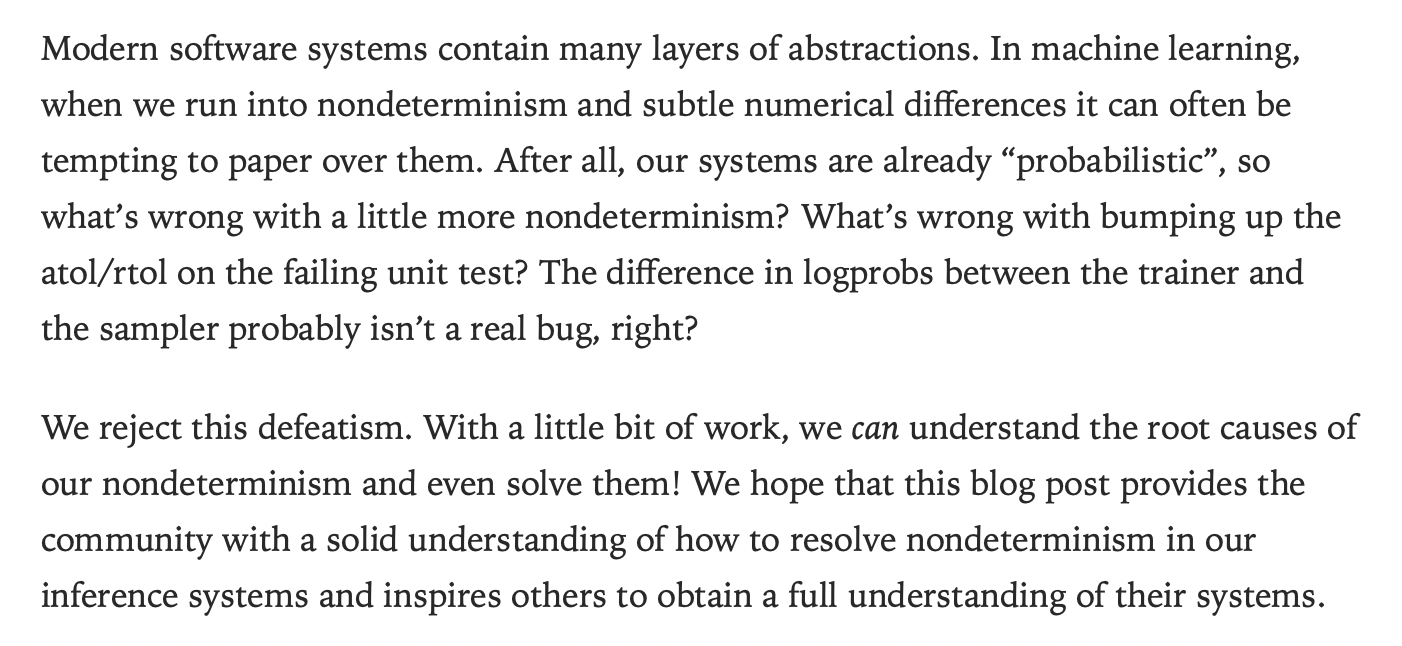

---

<a id="1" style="text-decoration: none; color: inherit;"><sup>1</sup></a><a href="https://onnx.ai/onnx/intro/concepts.html">https://onnx.ai/onnx/intro/concepts.html</a>

<a id="2" style="text-decoration: none; color: inherit;"><sup>2</sup></a><a href="https://onnxruntime.ai">https://onnxruntime.ai</a>

<a id="3" style="text-decoration: none; color: inherit;"><sup>3</sup></a><a href="https://developer.apple.com/documentation/coreml">https://developer.apple.com/documentation/coreml</a>

<a id="4" style="text-decoration: none; color: inherit;"><sup>4</sup></a><a href="https://en.wikipedia.org/wiki/Single-precision_floating-point_format">https://en.wikipedia.org/wiki/Single-precision_floating-point_format</a>

<a id="5" style="text-decoration: none; color: inherit;"><sup>5</sup></a><a href=" https://en.wikipedia.org/wiki/Half-precision_floating-point_format">https://en.wikipedia.org/wiki/Half-precision_floating-point_format</a>

<a id="6" style="text-decoration: none; color: inherit;"><sup>6</sup></a><a href="https://floating-point-gui.de/formats/fp/">https://floating-point-gui.de/formats/fp/</a>

<a id="7" style="text-decoration: none; color: inherit;"><sup>7</sup></a><a href="https://apple.github.io/coremltools/mlmodel/Format/NeuralNetwork.html">https://apple.github.io/coremltools/mlmodel/Format/NeuralNetwork.html</a>

<a id="8" style="text-decoration: none; color: inherit;"><sup>8</sup></a><a href="https://apple.github.io/coremltools/docs-guides/source/typed-execution.html">https://apple.github.io/coremltools/docs-guides/source/typed-execution.html</a>

<a id="9" style="text-decoration: none; color: inherit;"><sup>9</sup></a><a href="https://github.com/microsoft/onnxruntime/issues/21271#issuecomment-3637845056">https://github.com/microsoft/onnxruntime/issues/21271#issuecomment-3637845056</a>

<a id="10" style="text-decoration: none; color: inherit;"><sup>10</sup></a><a href="https://www.modular.com/blog/democratizing-ai-compute-part-8-what-about-the-mlir-compiler-infrastructure">https://www.modular.com/blog/democratizing-ai-compute-part-8-what-about-the-mlir-compiler-infrastructure</a>